In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
# Imports here
%matplotlib inline
%config InlinBackend.figure_format = 'retina'
import numpy as np
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import ast
import torchvision.transforms as transforms
from torchvision import datasets, models, transforms
import torchvision.models as models
from torch.autograd import Variable
from collections import OrderedDict
from PIL import Image
import json
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
data_dir = 'data_small/flower_data'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# TODO: Define your transforms for the training, validation, and testing sets

# Define transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
])
# TODO: Load the datasets with ImageFolder

# Load datasets 
train_ds = datasets.ImageFolder(train_dir, train_transforms)
valid_ds = datasets.ImageFolder(valid_dir, val_test_transforms)
test_ds = datasets.ImageFolder(test_dir, val_test_transforms)

# TODO: Using the image datasets and the trainforms, define the dataloaders

# Create dataloaders
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_ds, batch_size=64)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64)

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
with open('data_small/cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# TODO: Build and train your network

# VGG16 Model
model = models.vgg16(pretrained=True)
for param in model.parameters():
    param.requires_grad = False   

# Classifier 
model.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.2),     
    nn.Linear(512, 102), 
    nn.LogSoftmax(dim=1)
)

# Move model to GPU
# model = model.to('cuda')

# Loss and Optimizer
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Train the model
epochs = 1 #10
print_every = 100
steps = 0

for e in range(epochs):
    running_loss = 0
    for inputs, labels in train_loader:
        steps += 1
#         inputs, labels = inputs.to('cuda'), labels.to('cuda')
        
        # Forward
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if steps % print_every == 0:
            model.eval() 
            # Validation
            val_loss = 0
            accuracy = 0
            
            for inputs, labels in valid_loader:
#                 inputs, labels = inputs.to('cuda'), labels.to('cuda')
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                ps = torch.exp(outputs)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                accuracy += torch.mean(equals.type(torch.FloatTensor))
            
            print(f"Epoch {e+1}/{epochs}.. "
                  f"Step {steps}/{len(train_loader)}.. "
                  f"Loss: {running_loss/print_every:.3f}.. " 
                  f"Validation Loss: {val_loss/len(valid_loader):.3f}.."
                  f"Accuracy: {accuracy/len(valid_loader):.3f}")
            running_loss = 0
            model.train()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /tmp/xdg-cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 114MB/s]


In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# TODO: Do validation on the test set

# Load model 
model.eval()

# Testing loop
test_loss = 0 
accuracy = 0

with torch.no_grad():
    for inputs, labels in test_loader:
#         inputs, labels = inputs.to('cuda'), labels.to('cuda')
        
        logps = model(inputs) 
        batch_loss = criterion(logps, labels)
        
        test_loss += batch_loss.item()
        
        ps = torch.exp(logps)
        top_p, top_class = ps.topk(1, dim=1) 
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor))

# Print test loss and accuracy  
test_loss = test_loss / len(test_loader)
accuracy = accuracy / len(test_loader)

print(f"Test Loss: {test_loss:.3f}.. ")
print(f"Test Accuracy: {accuracy:.3f}")

Test Loss: 5.211.. 
Test Accuracy: 0.016


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# TODO: Save the checkpoint 

# Model class_to_idx
model.class_to_idx = train_ds.class_to_idx

checkpoint = {'input_size': 25088,
              'output_size': 102,
              'arch': 'vgg16',
              'learning_rate': 0.001,
              'batch_size': 64, 
              'epochs': epochs,
              'optimizer': optimizer.state_dict(),
              'classifier': model.classifier,
              'state_dict': model.state_dict(),
              'class_to_idx': model.class_to_idx}

torch.save(checkpoint, 'checkpoint.pth')

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# TODO: Write a function that loads a checkpoint and rebuilds the model

def load_checkpoint(filepath):
    checkpoint = torch.load(filepath)
    model = models.vgg16(pretrained=True) 
    for param in model.parameters():
        param.requires_grad = False
        
    model.class_to_idx = checkpoint['class_to_idx']
        
    model.classifier = checkpoint['classifier']
    model.load_state_dict(checkpoint['state_dict'])
    
    return model

# Usage:
model = load_checkpoint('checkpoint.pth')

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
def process_image(image_path):
    """Scales, crops, and normalizes a PIL image for a PyTorch model"""
    # TODO: Process a PIL image for use in a PyTorch model

    img = Image.open(image_path)
    
    transformations = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
    ])
    
    img_tensor = transformations(img)
    
    return img_tensor

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
def imshow(image, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    
    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image = image.numpy().transpose((1, 2, 0))
    
    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    
    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image = np.clip(image, 0, 1)
    
    ax.imshow(image)
    
    return ax

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
def predict(image_path, model, topk=5):
    """Make a prediction for an image using a trained model
    
    Params
    --------
        image_path (str): path to the image
        model (PyTorch model): trained model for inference
        topk (int): number of top predictions to return
    
    Returns
    --------
        probs (list): top prediction probabilities
        classes (list): top predicted classes
    """

    # Ensure model and image tensor on same device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    img_tensor = process_image(image_path)
    img_tensor = img_tensor.unsqueeze_(0).to(device)
    
    with torch.no_grad():              
        output = model.forward(img_tensor)
        ps = torch.exp(output).topk(topk)
            
        # Move preds back to CPU for processing   
        probs = ps[0].tolist()[0]
        classes = ps[1].cpu().tolist()[0]
        
    return probs, classes

KeyError: 90

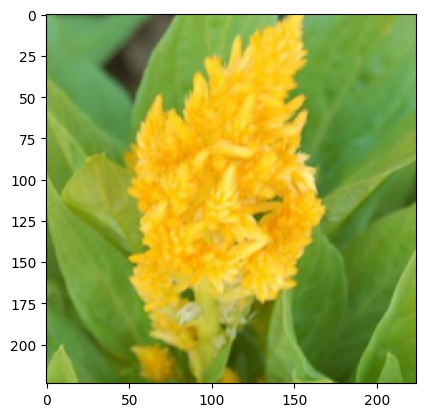

In [12]:
# --- [CELL 11]: ---
# cell_state: edited
# execution_status: {'status': 'error', 'done': True, 'execution_count': 12}
# === BEFORE (original) ===
# import matplotlib.pyplot as plt
# 
# # Display an image along with the top 5 classes
# def display_image(image_path):
#     img = process_image(image_path)
#     imshow(img)
# 
# model = load_checkpoint('checkpoint.pth')
# 
# # Testing with a random image from the test set
# test_image_path = np.random.choice(test_ds.imgs)[0]
# display_image(test_image_path)
# 
# probs, classes = predict(test_image_path, model)
# 
# class_names = [cat_to_name[cls] for cls in classes]
# 
# print("Probabilities:", probs)
# print("Classes:", class_names)
# 
# # Sanity check with a few random images from the test set
# for i in range(5):
#     test_image_path = np.random.choice(test_ds.imgs)[0]
#     display_image(test_image_path)
# 
#     probs, classes = predict(test_image_path, model)
# 
#     class_names = [cat_to_name[cls] for cls in classes]
# 
#     print("Probabilities:", probs)
#     print("Classes:", class_names)

# === AFTER (edited) ===
import matplotlib.pyplot as plt
import random


def display_image(image_path):
    img = process_image(image_path)
    imshow(img)

model = load_checkpoint('checkpoint.pth')

test_image_path = random.choice(test_ds.imgs)[0]
display_image(test_image_path)

probs, classes = predict(test_image_path, model)

class_names = [cat_to_name[cls] for cls in classes]

print("Probabilities:", probs)
print("Classes:", class_names)


for i in range(5):
    test_image_path = random.choice(test_ds.imgs)[0]
    display_image(test_image_path)

    probs, classes = predict(test_image_path, model)

    class_names = [cat_to_name[cls] for cls in classes]

    print("Probabilities:", probs)
    print("Classes:", class_names)

In [13]:
assert len(probs) == len(classes)
assert len(class_names) == len(classes)
assert all(str(cls) in cat_to_name for cls in classes)

NameError: name 'class_names' is not defined